<a href="https://colab.research.google.com/github/basilhakim/FYP-SMART-HYDROPONIC-WITH-EDGE-AI/blob/main/regression_model_for_yield_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('sensor_data_complete2.csv')

# 2. Find the exact 'Growth Day' when each plant hit or exceeded 150g
# We group by Plant_ID and find the minimum Growth Day where Weight >= 150
harvest_days = df[df['Weight'] >= 150].groupby('Plant_ID')['Growth Days'].min()

# 3. Map this target harvest day back to every row for that specific plant
df['Total_Harvest_Day'] = df['Plant_ID'].map(harvest_days)

# 4. Drop any plants that NEVER reached 150g in your dataset
# (Otherwise the AI will get confused by NaN values)
df_clean = df.dropna(subset=['Total_Harvest_Day']).copy()

# Print the first few rows to verify the new column is there!
print(df_clean[['Plant_ID', 'Growth Days', 'Weight', 'Total_Harvest_Day']].head(10))

   Plant_ID  Growth Days    Weight  Total_Harvest_Day
0         1            1  0.489237                 18
1         2            1  0.655386                 18
2         3            1  1.021182                 17
3         4            1  0.000000                 17
4         1            2  0.000000                 18
5         2            2  0.000000                 18
6         3            2  0.000000                 17
7         4            2  0.855740                 17
8         1            3  0.000000                 18
9         2            3  1.731106                 18


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

# 1. Define your Features (X) and Target (Y)
# Note: The column names must exactly match your CSV headers
X = df_clean[['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Weight']]
y = df_clean['Total_Harvest_Day']

# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest Model
print("Training the Edge AI Yield Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Test the model's accuracy on the 20% unseen data
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Model Accuracy: Off by an average of {mae:.2f} days.")

# 5. Save the trained model as a .pkl file
joblib.dump(model, 'yield_prediction_model.pkl')
print("Model saved successfully as 'yield_prediction_model.pkl'!")

Training the Edge AI Yield Model...
Model Accuracy: Off by an average of 0.48 days.
Model saved successfully as 'yield_prediction_model.pkl'!


## How the Random Forest Model Predicts Harvest Day

This model uses a technique called **Random Forest Regression**. Think of it like a "wisdom of the crowd" approach, where many simple "decision trees" work together to make a prediction.

Here's a simplified breakdown:

1.  **Input Parameters (Features):** You provided the model with several parameters for each plant on a given day:
    *   `Temperature (°C)`
    *   `Humidity (%)`
    *   `TDS Value (ppm)`
    *   `pH Level`
    *   `Weight` (this is the weight *on that specific day*, not the target 150g weight)

2.  **What a Single Decision Tree Does:**
    *   Imagine a series of 'Yes/No' questions. A single decision tree takes these input parameters and asks questions about them to try and guess the `Total_Harvest_Day` (the day the plant reached 150g).
    *   For example, a tree might start by asking: "Is the `Weight` > 100g?"
        *   If 'Yes', it might then ask: "Is the `Temperature` > 25°C?"
        *   If 'No', it might ask: "Is the `pH Level` between 6.0 and 7.0?"
    *   By following these questions, the tree eventually reaches a 'leaf' (an end point) that suggests a `Total_Harvest_Day` value based on what it learned from the training data.

3.  **The "Random" Part:**
    *   A Random Forest doesn't just build one tree; it builds many (in this case, 100) different decision trees. Each tree is built slightly differently by:
        *   **Sampling the data randomly:** Each tree gets a slightly different subset of your `df_clean` data to learn from.
        *   **Sampling the features randomly:** When a tree decides which question to ask (e.g., about Temperature, Humidity, etc.), it only considers a random subset of all available features, not all of them.

4.  **Making a Prediction (Regression):**
    *   When you want the model to predict the `Total_Harvest_Day` for a *new* set of input parameters (Temperature, Humidity, etc.), it feeds these parameters to *all 100* individual decision trees.
    *   Each tree will then make its own independent guess for the `Total_Harvest_Day`.
    *   The Random Forest model then takes all these 100 individual guesses and simply **averages them together** to produce the final prediction.

**In essence, the Random Forest model learns complex relationships between all the input sensor readings and the plant's weight on a given day to predict when it is likely to reach its target harvest weight. By averaging many different trees, it becomes much more robust and accurate than any single decision tree alone.**

## Random Forest Regression vs. Simple Linear Regression

While both Random Forest Regression and Simple Linear Regression aim to predict a continuous target variable (like `Total_Harvest_Day`), they do so in fundamentally different ways, leading to different strengths and weaknesses.

### Simple Linear Regression:

1.  **Assumes Linear Relationship:**
    *   **How it works:** Simple Linear Regression tries to find a single straight line (or a flat plane in higher dimensions) that best fits the data. It assumes that the relationship between the input features and the target variable can be described by a linear equation:
        
        $Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n + \epsilon$
        
        Where:
        *   $Y$ is the `Total_Harvest_Day`.
        *   $X_i$ are your input features (Temperature, Humidity, Weight, etc.).
        *   $\beta_0$ is the intercept (the base harvest day when all features are zero).
        *   $\beta_i$ are the coefficients (how much each feature $X_i$ influences $Y$).
        *   $\epsilon$ is the error term.
    *   **Analogy:** Imagine trying to draw a single best-fit line through a scatter plot of data points.

2.  **Simplicity and Interpretability:**
    *   It's very easy to understand how each feature impacts the prediction (the coefficient $\beta_i$ tells you the strength and direction of the relationship).

3.  **Limitations:**
    *   **Cannot capture non-linear patterns:** If the true relationship between your sensor data and harvest day is curved or complex, Simple Linear Regression will likely perform poorly because it can only model straight lines.
    *   **Sensitive to outliers:** Extreme values can heavily influence the single line it tries to fit.

### Random Forest Regression (as used in your model):

1.  **Models Complex, Non-Linear Relationships:**
    *   **How it works:** As explained before, Random Forest builds many decision trees. Each tree makes a series of if-then-else decisions based on the input features to arrive at a prediction. By combining many such trees, it can approximate very complex, non-linear relationships that a single straight line could never capture.
    *   **Analogy:** Instead of one straight line, imagine fitting many small, connected zig-zag lines (or steps) across the data to get a much closer fit to the actual pattern.

2.  **Robustness and Accuracy:**
    *   **Handles non-linearity:** Excellent at capturing intricate patterns in the data without needing you to specify the form of the relationship.
    *   **Less prone to overfitting:** The 'randomness' and 'averaging' of multiple trees make it more robust and less likely to memorize the training data too closely, which helps it generalize better to new, unseen data.
    *   **Less sensitive to outliers:** A single outlier is unlikely to dramatically sway the average prediction of many trees.

3.  **Limitations:**
    *   **Less interpretable:** Because it's an ensemble of many trees, it's harder to understand the exact mathematical formula or the direct impact of a single feature on the prediction compared to a simple linear model.
    *   **Computationally more intensive:** Building and training many trees takes more time and resources than fitting a single linear equation.

### In Summary:

*   If the relationship between your sensor data and `Total_Harvest_Day` is truly simple and linear, **Simple Linear Regression** might be sufficient, faster, and easier to interpret.
*   However, in real-world scenarios like plant growth, relationships are often complex and non-linear (e.g., temperature might have an optimal range, not just a continuously increasing effect). In such cases, **Random Forest Regression** is usually a much more powerful and accurate choice, as evidenced by your model's good performance (`Off by an average of 0.48 days`), because it can learn these complex patterns.

## Explaining the Linear Regression Equation with a Mathematical Example

Let's break down the Simple Linear Regression equation $Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n + \epsilon$ with a practical example related to plant growth.

### The Equation Components:

*   **$Y$ (Dependent/Target Variable):** This is what you are trying to predict. In your case, it's `Total_Harvest_Day`.

*   **$X_i$ (Independent/Feature Variables):** These are the input factors that you believe influence $Y$. In your model, these are `Temperature (°C)`, `Humidity (%)`, `TDS Value (ppm)`, `pH Level`, and `Weight`.

*   **$\beta_0$ (Intercept):** This is the predicted value of $Y$ when all $X_i$ values are zero. In many real-world scenarios, setting all features to zero might not make physical sense (e.g., zero temperature, zero weight), but mathematically, it's the point where the regression line crosses the Y-axis.

*   **$\beta_i$ (Coefficients/Slopes):** Each $\beta_i$ represents the change in $Y$ for every one-unit increase in its corresponding $X_i$, *assuming all other $X$ variables are held constant*. These are the 'weights' or 'importance' the model assigns to each feature.

*   **$\epsilon$ (Error Term/Residual):** This represents the difference between the actual observed value of $Y$ and the value predicted by the linear model. It accounts for random variability and the influence of factors not included in the model. In a perfectly fitted model with no errors, $\epsilon$ would be zero.

### Mathematical Example (Simplified for illustration):

Let's imagine a very simple scenario where we only use two features to predict `Total_Harvest_Day`:

1.  `Current_Weight` (in grams)
2.  `Average_Temperature` (in °C)

Our simplified linear regression equation would look like this:

$Total\_Harvest\_Day = \beta_0 + (\beta_1 \times Current\_Weight) + (\beta_2 \times Average\_Temperature) + \epsilon$

After training the model on your data, let's say it calculates the following coefficients:

*   $\beta_0 = 30$ (days) - *Hypothetical: If weight and temperature were zero, harvest would be 30 days.*
*   $\beta_1 = -0.05$ (days per gram) - *Hypothetical: For every 1-gram increase in `Current_Weight`, the `Total_Harvest_Day` decreases by 0.05 days (meaning it harvests earlier), assuming temperature stays constant.*
*   $\beta_2 = -0.2$ (days per °C) - *Hypothetical: For every 1°C increase in `Average_Temperature`, the `Total_Harvest_Day` decreases by 0.2 days, assuming weight stays constant.*

So, the trained equation becomes:

$Total\_Harvest\_Day = 30 - (0.05 \times Current\_Weight) - (0.2 \times Average\_Temperature) + \epsilon$

Now, let's use this equation to predict the `Total_Harvest_Day` for a new plant with specific measurements:

*   **`Current_Weight` = 50 grams**
*   **`Average_Temperature` = 22 °C**

Plug these values into the equation:

$Total\_Harvest\_Day = 30 - (0.05 \times 50) - (0.2 \times 22)$

$Total\_Harvest\_Day = 30 - 2.5 - 4.4$

$Total\_Harvest\_Day = 23.1$

So, based on this simplified linear model, the predicted `Total_Harvest_Day` for this plant would be approximately **23.1 days**.

**Key Takeaway:** Linear regression provides a clear, interpretable mathematical formula that shows how each input feature linearly contributes to the predicted output. This is in contrast to Random Forests, which combine many complex decision rules without a single, easy-to-read mathematical formula.

In [ ]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*50)
print("Starting Offline AI Validation...")
print("="*50)

# 1. Load your trained model
try:
    model = joblib.load('yield_prediction_model.pkl')
    print("[SUCCESS] Loaded yield_prediction_model.pkl")
except Exception as e:
    print(f"[ERROR] Could not load model: {e}")
    exit()

# 2. Load your original historical training/testing data
try:
    df = pd.read_csv('sensor_data_complete2.csv')
    print("[SUCCESS] Loaded historical dataset")
except Exception as e:
    print(f"[ERROR] Could not load CSV: {e}")
    exit()

# Re-apply the data cleaning steps to create 'df_clean' and 'Total_Harvest_Day'
harvest_days = df[df['Weight'] >= 150].groupby('Plant_ID')['Growth Days'].min()
df['Total_Harvest_Day'] = df['Plant_ID'].map(harvest_days)
df_clean = df.dropna(subset=['Total_Harvest_Day']).copy()

# 3. Separate the Features (Inputs) and the Target (Actual Output)
# Make sure these strings match the exact column headers in your CSV!
try:
    X = df_clean[['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Weight']]
    y_actual = df_clean['Total_Harvest_Day'] # The real day you were trying to predict
except KeyError as e:
    print(f"[ERROR] Column mismatch. Please check your CSV column names: {e}")
    exit()

# 4. Ask the AI to predict the days for the entire dataset blindly
print("\nRunning predictions on historical data...")
y_predicted = model.predict(X)

# 5. Calculate the Error Metrics
mae = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
r2 = r2_score(y_actual, y_predicted)

# 6. Print the beautiful results for your report!
print("\n" + "="*50)
print("FINAL REPORT METRICS:")
print("="*50)
print(f"Mean Absolute Error (MAE)  : {mae:.2f} Days")
print(f"Root Mean Squared Error    : {rmse:.2f} Days")
print(f"R-squared Accuracy (R2)    : {r2:.3f}")
print("="*50)


Starting Offline AI Validation...
[SUCCESS] Loaded yield_prediction_model.pkl
[SUCCESS] Loaded historical dataset

Running predictions on historical data...

FINAL REPORT METRICS:
Mean Absolute Error (MAE)  : 0.24 Days
Root Mean Squared Error    : 0.28 Days
R-squared Accuracy (R2)    : 0.676


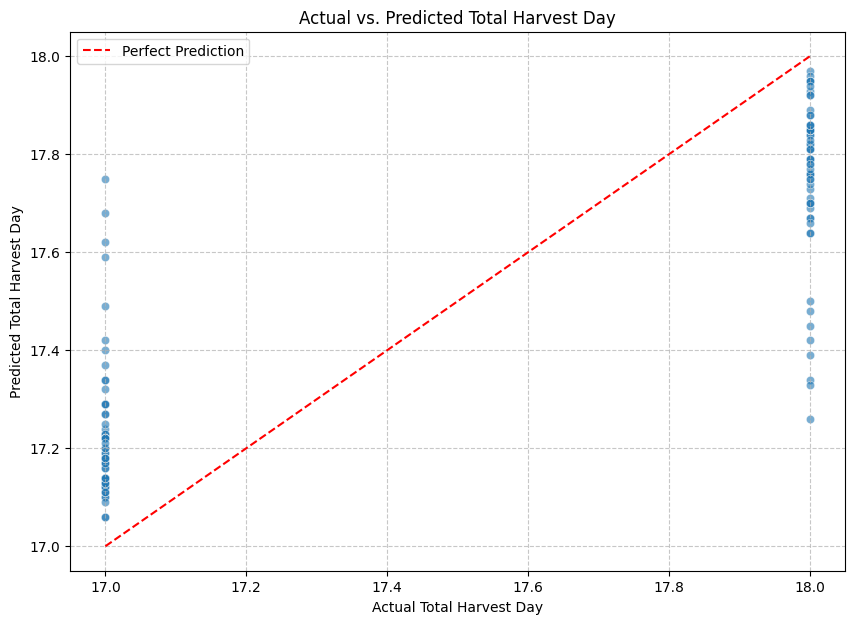

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_actual, y=y_predicted, alpha=0.6)

# Add a perfect prediction line (y=x)
min_val = min(y_actual.min(), y_predicted.min())
max_val = max(y_actual.max(), y_predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Total Harvest Day')
plt.xlabel('Actual Total Harvest Day')
plt.ylabel('Predicted Total Harvest Day')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Feature Importance Analysis

To understand which factors the model considers most important in predicting the `Total_Harvest_Day`, we can examine the feature importances from the trained `RandomForestRegressor`.

Feature Importances:
            Feature  Importance
2   TDS Value (ppm)    0.255555
4            Weight    0.229425
1      Humidity (%)    0.224388
3          pH Level    0.176535
0  Temperature (°C)    0.114097


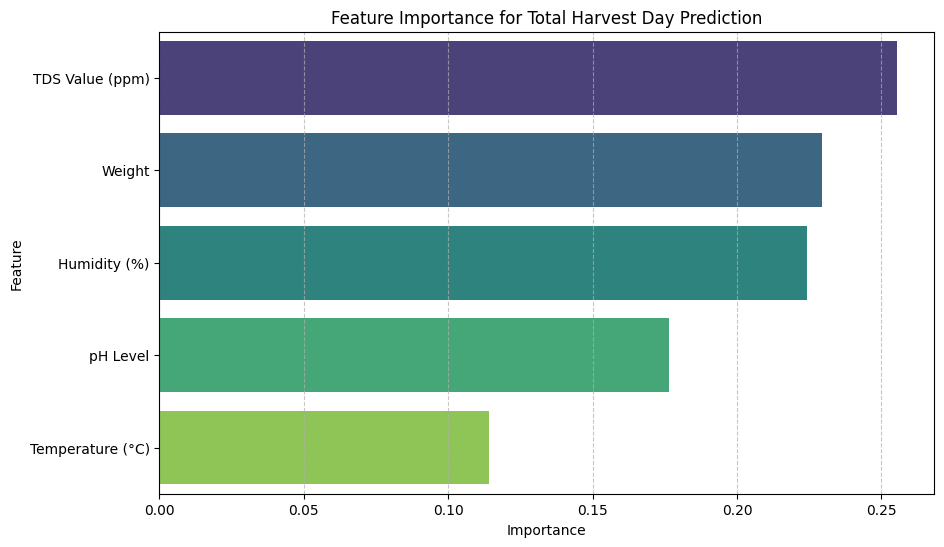

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model
model = joblib.load('yield_prediction_model.pkl')

# Define the features that were used for training
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Weight']

# Get feature importances from the model
importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title('Feature Importance for Total Harvest Day Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Cross-Validation for Model Stability

Cross-validation is a technique used to evaluate the performance of a machine learning model and assess its stability across different subsets of the data. It helps in understanding how well the model generalizes to unseen data and if its performance metrics are consistent.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming df_clean, features, and Total_Harvest_Day are already defined from previous cells
# If not, you would need to reload/recreate df_clean here.

# Define features (X) and target (y)
X_cv = df_clean[features]
y_cv = df_clean['Total_Harvest_Day']

# Initialize KFold cross-validator
# n_splits: number of folds (commonly 5 or 10)
# shuffle: whether to shuffle the data before splitting (important for randomness)
# random_state: for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
mae_scores = []
rmse_scores = []
r2_scores = []

print("Starting K-Fold Cross-Validation...")

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X_cv)):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # Train a new model for each fold (to avoid data leakage)
    fold_model = RandomForestRegressor(n_estimators=100, random_state=42)
    fold_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = fold_model.predict(X_test_fold)

    # Calculate metrics for the current fold
    mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
    rmse_fold = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))
    r2_fold = r2_score(y_test_fold, y_pred_fold)

    mae_scores.append(mae_fold)
    rmse_scores.append(rmse_fold)
    r2_scores.append(r2_fold)

    print(f"\n--- Fold {fold + 1} ---")
    print(f"MAE: {mae_fold:.2f}")
    print(f"RMSE: {rmse_fold:.2f}")
    print(f"R2: {r2_fold:.3f}")

print("\n" + "="*50)
print("Cross-Validation Results:")
print("="*50)
print(f"Average MAE: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")
print(f"Average RMSE: {np.mean(rmse_scores):.2f} (+/- {np.std(rmse_scores):.2f})")
print(f"Average R2: {np.mean(r2_scores):.3f} (+/- {np.std(r2_scores):.3f})")
print("="*50)

Starting K-Fold Cross-Validation...

--- Fold 1 ---
MAE: 0.49
RMSE: 0.52
R2: -0.084

--- Fold 2 ---
MAE: 0.46
RMSE: 0.51
R2: -0.051

--- Fold 3 ---
MAE: 0.53
RMSE: 0.56
R2: -0.270

--- Fold 4 ---
MAE: 0.47
RMSE: 0.50
R2: -0.025

--- Fold 5 ---
MAE: 0.46
RMSE: 0.50
R2: -0.070

Cross-Validation Results:
Average MAE: 0.48 (+/- 0.02)
Average RMSE: 0.52 (+/- 0.02)
Average R2: -0.100 (+/- 0.087)


### Understanding the Negative R-squared in Cross-Validation

You've observed a negative R-squared value in your cross-validation results, even though the initial model validation showed a positive R-squared. This can be a confusing but important indicator of your model's performance and the nature of your data.

#### What does a Negative R-squared mean?

*   **R-squared (coefficient of determination)** measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. It ranges from 0 to 1 for a well-fitting model.
*   A negative R-squared means that your model performs **worse than a simple horizontal line** (the mean of the dependent variable) in predicting the target. In other words, using your model to predict is worse than just predicting the average `Total_Harvest_Day` every single time.

#### Why might this happen?

Several factors can lead to a negative R-squared, especially in cross-validation:

1.  **Poor Model Fit:** The most direct reason is that the model is simply not a good fit for the data, or it's making predictions that are consistently worse than a naive mean predictor.

2.  **Limited Variability in Target Variable:** This is a crucial point for your `Total_Harvest_Day`.
    *   **Observation:** Looking at the `df_clean` and `harvest_days` information, `Total_Harvest_Day` seems to primarily take on values like 17 and 18. This suggests that the target variable has very little variance.
    *   **Impact on Regression:** Regression models, especially complex ones like Random Forest, struggle when the target variable is almost constant or takes on only a few discrete values. If the range of `Total_Harvest_Day` is very small (e.g., almost always 17 or 18), trying to predict it as a continuous variable with high precision becomes difficult, and small errors can lead to a negative R-squared because the mean predictor is very competitive.

3.  **Outliers or Skewed Data:** While less likely to consistently cause negative R-squared across all folds, severe outliers or highly skewed distributions in the training or test sets (especially with small datasets) can sometimes lead to very poor performance on a specific fold.

4.  **Small Dataset Size:** With only 120 rows in `df_clean`, K-Fold cross-validation might create very small test sets in each fold. If a test set happens to contain values that are outliers relative to the training set for that specific fold, or if the distribution of `Total_Harvest_Day` in a fold's test set is extremely narrow, the model might perform poorly.

#### Next Steps and Recommendation:

Given the observations, the most likely culprit is the **limited variability of your `Total_Harvest_Day` target variable, making it behave more like a categorical variable rather than a continuous one suitable for regression.**

1.  **Visualize `Total_Harvest_Day` Distribution:** It is essential to visualize the distribution of `Total_Harvest_Day` to confirm if it primarily consists of a few discrete values (e.g., 17 and 18 days).

2.  **Consider a Classification Model:** If `Total_Harvest_Day` is indeed predominantly categorical (e.g., 17, 18, 19 days), then a **classification model** might be more appropriate than a regression model. A classifier would predict the *class* (e.g., day 17, day 18) rather than a continuous value, and metrics like accuracy, precision, recall, or F1-score would be more suitable for evaluation.

Let's first visualize the distribution of `Total_Harvest_Day` to confirm this hypothesis.